<a href="https://colab.research.google.com/github/mkane968/digital-text-methods/blob/main/Tutorial_6_Frequency_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 6: Frequency Analysis

Frequency analysis asks a simple question:

> **What occurs most often in a text or corpus?**

Word counts are one of the foundations of corpus analysis. In this tutorial, we will move from raw counts to **normalized frequencies** and comparisons across groups.

### In this tutorial, we will:
- count words with `Counter`
- identify the most frequent words
- compare raw and normalized frequency
- examine frequencies across texts
- compare groups using metadata
- visualize frequent words
- consider the difference between frequency and significance


## 1. Create a Small Corpus

We will use a small example corpus stored in a pandas DataFrame. Each row represents one text, while the other columns contain metadata.


In [1]:
import pandas as pd

authors = ["Author A", "Author B", "Author C", "Author D", "Author E", "Author F"]
genres = ["fiction", "fiction", "fiction", "poetry", "poetry", "poetry"]

texts = [
    "The dark house stood beside the quiet garden. The house was old and dark.",
    "The child walked through the house and opened the old door.",
    "The garden was quiet at night. A dark bird rested beside the house.",
    "The moon shone over the quiet sea. The night was cold and still.",
    "The sea moved beneath the moon. The dark night covered the shore.",
    "A bird crossed the moon and disappeared into the quiet night."
]

df = pd.DataFrame(
    list(zip(authors, genres, texts)),
    columns=["author", "genre", "text"]
)

df


,author,genre,text
0,Author A,fiction,The dark house stood beside the quiet garden. ...
1,Author B,fiction,The child walked through the house and opened ...
2,Author C,fiction,The garden was quiet at night. A dark bird res...
3,Author D,poetry,The moon shone over the quiet sea. The night w...
4,Author E,poetry,The sea moved beneath the moon. The dark night...
5,Author F,poetry,A bird crossed the moon and disappeared into t...


## 2. Prepare the Text

For this introductory frequency analysis, we will use a simple preprocessing function with spaCy.

We will lowercase words, remove punctuation and stopwords, and use lemmas.

Remember: these are **methodological choices**, not universal requirements.


In [2]:
import spacy

nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    doc = nlp(text)
    return [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    ]

df["tokens"] = df["text"].apply(preprocess)

df


,author,genre,text,tokens
0,Author A,fiction,The dark house stood beside the quiet garden. ...,"[dark, house, stand, quiet, garden, house, old..."
1,Author B,fiction,The child walked through the house and opened ...,"[child, walk, house, open, old, door]"
2,Author C,fiction,The garden was quiet at night. A dark bird res...,"[garden, quiet, night, dark, bird, rest, house]"
3,Author D,poetry,The moon shone over the quiet sea. The night w...,"[moon, shine, quiet, sea, night, cold]"
4,Author E,poetry,The sea moved beneath the moon. The dark night...,"[sea, move, beneath, moon, dark, night, cover,..."
5,Author F,poetry,A bird crossed the moon and disappeared into t...,"[bird, cross, moon, disappear, quiet, night]"


## 3. Count Words in the Corpus

Recall `Counter` from our earlier tutorials.

First, combine the tokens from all texts:


In [3]:
from collections import Counter

all_words = [
    word
    for tokens in df["tokens"]
    for word in tokens
]

word_counts = Counter(all_words)

word_counts


Counter({'dark': 4,
         'house': 4,
         'stand': 1,
         'quiet': 4,
         'garden': 2,
         'old': 2,
         'child': 1,
         'walk': 1,
         'open': 1,
         'door': 1,
         'night': 4,
         'bird': 2,
         'rest': 1,
         'moon': 3,
         'shine': 1,
         'sea': 2,
         'cold': 1,
         'move': 1,
         'beneath': 1,
         'cover': 1,
         'shore': 1,
         'cross': 1,
         'disappear': 1})

We can ask for the ten most frequent words:


In [4]:
word_counts.most_common(10)


[('dark', 4),
 ('house', 4),
 ('quiet', 4),
 ('night', 4),
 ('moon', 3),
 ('garden', 2),
 ('old', 2),
 ('bird', 2),
 ('sea', 2),
 ('stand', 1)]

The number beside each word is its **raw frequency**: the number of times that word occurs in the corpus.

A frequent word is not automatically an important or meaningful word. Frequency tells us what is common; interpretation requires us to consider context and our research question.


## 4. Count a Specific Word

We can retrieve the frequency of one word:


In [5]:
word_counts["dark"]


4

Try replacing `"dark"` with another word from the corpus.


## 5. Frequency by Text

Frequency can also be calculated separately for each document.

Let's count the word `dark` in each text:


In [6]:
df["dark_count"] = df["tokens"].apply(lambda words: words.count("dark"))

df[["author", "genre", "dark_count"]]


,author,genre,dark_count
0,Author A,fiction,2
1,Author B,fiction,0
2,Author C,fiction,1
3,Author D,poetry,0
4,Author E,poetry,1
5,Author F,poetry,0


This allows us to see **where** a word occurs rather than only how often it occurs in the corpus overall.


## 6. Why Raw Counts Can Be Misleading

Imagine that one text contains 1,000 words and another contains 10,000 words.

If `dark` occurs:

- 5 times in the 1,000-word text
- 20 times in the 10,000-word text

the second text has more occurrences—but it is also ten times longer.

To compare texts of different lengths, corpus researchers often use **normalized frequency**.


In [7]:
df["word_count"] = df["tokens"].apply(len)

df[["author", "genre", "word_count", "dark_count"]]


,author,genre,word_count,dark_count
0,Author A,fiction,8,2
1,Author B,fiction,6,0
2,Author C,fiction,7,1
3,Author D,poetry,6,0
4,Author E,poetry,8,1
5,Author F,poetry,6,0


## 7. Normalized Frequency

A normalized frequency expresses a count relative to the amount of text.

For a large corpus, frequencies are often reported **per 1,000**, **10,000**, or **million words**.

For this small example, we will calculate occurrences per 1,000 words:

**normalized frequency = raw count ÷ total words × 1,000**


In [8]:
df["dark_per_1000"] = (
    df["dark_count"] / df["word_count"] * 1000
)

df[["author", "genre", "dark_count", "word_count", "dark_per_1000"]]


,author,genre,dark_count,word_count,dark_per_1000
0,Author A,fiction,2,8,250.000000
1,Author B,fiction,0,6,0.000000
2,Author C,fiction,1,7,142.857143
3,Author D,poetry,0,6,0.000000
4,Author E,poetry,1,8,125.000000
5,Author F,poetry,0,6,0.000000


Normalized frequency makes comparisons fairer when texts or groups contain different amounts of language.


## 8. Comparing Groups

Metadata allows us to compare subsets of a corpus.

For example, how often does `dark` occur in our fiction and poetry texts?


In [9]:
genre_counts = df.groupby("genre").agg(
    dark_count=("dark_count", "sum"),
    word_count=("word_count", "sum")
)

genre_counts["dark_per_1000"] = (
    genre_counts["dark_count"] /
    genre_counts["word_count"] * 1000
)

genre_counts


,dark_count,word_count,dark_per_1000
genre,,,
fiction,3,21,142.857143
poetry,1,20,50.000000


This basic workflow can be used to compare words across:

- genres
- authors
- historical periods
- publication venues
- disciplines
- other categories represented in your metadata

Be careful with very small groups. A numerical difference is not automatically a meaningful difference.


## 9. Visualizing Frequent Words

A simple bar chart can make a frequency distribution easier to inspect.


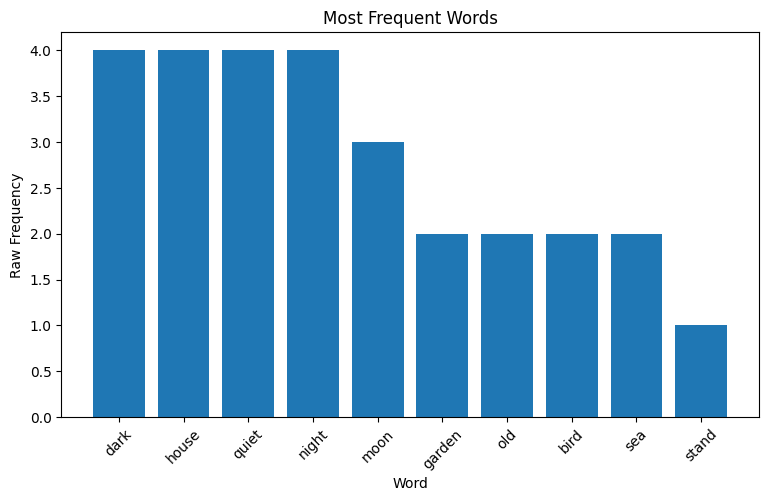

In [10]:
import matplotlib.pyplot as plt

top_words = word_counts.most_common(10)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(9, 5))
plt.bar(words, counts)
plt.xlabel("Word")
plt.ylabel("Raw Frequency")
plt.title("Most Frequent Words")
plt.xticks(rotation=45)
plt.show()


A visualization can reveal patterns quickly, but it does not explain **why** those patterns occur. Return to the texts and metadata when interpreting results.


## 10. From Counting to Interpretation

Frequency analysis often follows this workflow:

**Corpus → Preprocessing → Tokens → Counts → Normalize → Compare → Interpret**

As you interpret frequencies, ask:

1. Is this word genuinely frequent, or is the corpus/group simply larger?
2. How is the word distributed across individual texts?
3. Does one text account for most of the occurrences?
4. What does the word mean in context?
5. What can frequency tell us—and what can it not tell us?


## Try It Yourself

Using the example corpus:

1. Choose a word other than `dark`.
2. Calculate its raw frequency in the whole corpus.
3. Calculate its frequency in each text.
4. Calculate its normalized frequency per 1,000 words.
5. Compare its normalized frequency across fiction and poetry.
6. In a text cell, explain what the numbers suggest and what you would need to investigate before making an interpretive claim.


## References and Additional Resources

- **NLTK Book: Natural Language Processing with Python**  
  https://www.nltk.org/book/

- **Introduction to Cultural Analytics & Python — Melanie Walsh**  
  https://melaniewalsh.github.io/Intro-Cultural-Analytics/

- **pandas Documentation**  
  https://pandas.pydata.org/docs/

- **spaCy 101**  
  https://spacy.io/usage/spacy-101


**AI Use Disclosure:** This tutorial was developed by the instructor with assistance from AI tools for drafting and refining explanations, examples, and Python code. All materials were reviewed, edited, and adapted by the instructor for this course.